In [1]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

In [2]:
df1 = df

In [3]:
df1.head(5)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    str    
 3   smoker      244 non-null    str    
 4   day         244 non-null    str    
 5   time        244 non-null    str    
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), str(4)
memory usage: 17.3 KB


In [5]:
df1.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [6]:
df1.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [7]:
df1.duplicated().sum()

np.int64(1)

In [8]:
df1.index

RangeIndex(start=0, stop=244, step=1)

In [9]:
df1.tail()

,total_bill,tip,sex,smoker,day,time,size
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
243,18.78,3.00,Female,No,Thur,Dinner,2


In [10]:
df1.duplicated().sum()

np.int64(1)

In [11]:
df1 = df1.drop_duplicates()

In [12]:
df1.columns = df1.columns.str.strip().str.lower()

In [13]:
df1.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [14]:
df1["tip_pct"] = df1["tip"] / df1["total_bill"]

In [15]:
df1.head(10)

,total_bill,tip,sex,smoker,day,time,size,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,0.059447
1,10.34,1.66,Male,No,Sun,Dinner,3,0.160542
2,21.01,3.50,Male,No,Sun,Dinner,3,0.166587
3,23.68,3.31,Male,No,Sun,Dinner,2,0.139780
4,24.59,3.61,Female,No,Sun,Dinner,4,0.146808
5,25.29,4.71,Male,No,Sun,Dinner,4,0.186240
6,8.77,2.00,Male,No,Sun,Dinner,2,0.228050
7,26.88,3.12,Male,No,Sun,Dinner,4,0.116071
8,15.04,1.96,Male,No,Sun,Dinner,2,0.130319
9,14.78,3.23,Male,No,Sun,Dinner,2,0.218539


In [19]:
df1.info()

<class 'pandas.DataFrame'>
Index: 243 entries, 0 to 243
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  243 non-null    float64 
 1   tip         243 non-null    float64 
 2   sex         243 non-null    category
 3   smoker      243 non-null    category
 4   day         243 non-null    category
 5   time        243 non-null    category
 6   size        243 non-null    int64   
 7   tip_pct     243 non-null    float64 
dtypes: category(4), float64(3), int64(1)
memory usage: 10.7 KB


In [18]:
df1 = df1.astype({
    'day' : 'category',
    'time' : 'category',
    'smoker' : 'category',
    'sex' : 'category'
})

In [21]:
df1.describe()

,total_bill,tip,size,tip_pct
count,243.000000,243.000000,243.000000,243.000000
mean,19.813868,3.002387,2.572016,0.160831
std,8.910071,1.385002,0.952356,0.061197
min,3.070000,1.000000,1.000000,0.035638
25%,13.380000,2.000000,2.000000,0.128833
50%,17.810000,2.920000,2.000000,0.155219
75%,24.175000,3.575000,3.000000,0.191746
max,50.810000,10.000000,6.000000,0.710345


In [26]:
Q1 = df1["total_bill"].quantile(0.25)
Q3 = df1["total_bill"].quantile(0.75)
IQR  = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df1.query("total_bill < @lower_bound or total_bill > @upper_bound")
outliers

,total_bill,tip,sex,smoker,day,time,size,tip_pct
59,48.27,6.73,Male,No,Sat,Dinner,4,0.139424
102,44.30,2.50,Female,Yes,Sat,Dinner,3,0.056433
142,41.19,5.00,Male,No,Thur,Lunch,5,0.121389
156,48.17,5.00,Male,No,Sun,Dinner,6,0.103799
170,50.81,10.00,Male,Yes,Sat,Dinner,3,0.196812
182,45.35,3.50,Male,Yes,Sun,Dinner,3,0.077178
184,40.55,3.00,Male,Yes,Sun,Dinner,2,0.073983
197,43.11,5.00,Female,Yes,Thur,Lunch,4,0.115982
212,48.33,9.00,Male,No,Sat,Dinner,4,0.186220


## data analyzing
---

# which day people gave more tips

In [52]:
day_avg_tip = df1.groupby('day')['tip_pct'].mean().sort_values(ascending=False)
day_avg_tip

day
Fri     0.169913
Sun     0.166897
Thur    0.161397
Sat     0.153152
Name: tip_pct, dtype: float64

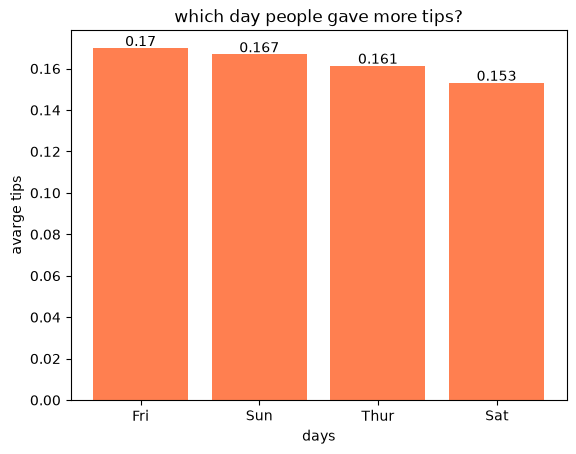

In [62]:
plt.bar(day_avg_tip.index,day_avg_tip.values,color="coral")
plt.xlabel("days")
plt.ylabel("avarge tips")
plt.title("which day people gave more tips?")
for i in range(len(day_avg_tip.values)):
    plt.text(i,day_avg_tip.values[i]+ 0.001, str(round(day_avg_tip.values[i],3)), ha='center')

plt.show()


## Bar Chart Summary

As you can see, **friday and sunday** has the highest average tip%, while **saturday** has the lowest compared to other days.

---

## Question: Do smokers tip a higher or lower percentage than non-smokers?

In [58]:
smoker_avg_tip = df1.groupby("smoker")["tip_pct"].mean()
smoker_avg_tip

smoker
No     0.159328
Yes    0.163298
Name: tip_pct, dtype: float64

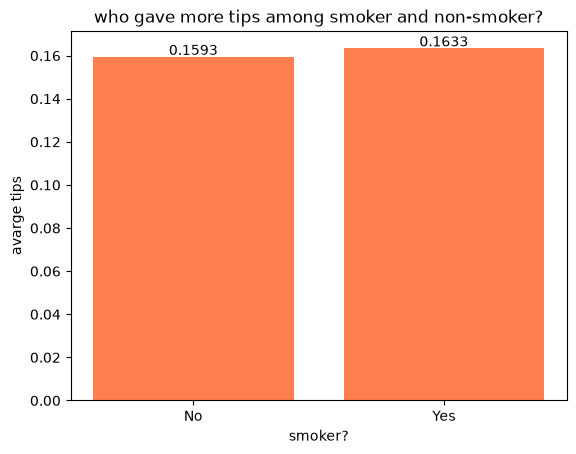

In [61]:
plt.bar(smoker_avg_tip.index,smoker_avg_tip.values,color="coral")
plt.xlabel("smoker?")
plt.ylabel("avarge tips")
plt.title("who gave more tips among smoker and non-smoker?")
for i in range(len(smoker_avg_tip.values)):
    plt.text(i,smoker_avg_tip.values[i] + 0.001, str(round(smoker_avg_tip.values[i],4)), ha='center')

plt.show()


# Party Size vs. Tip Percentage

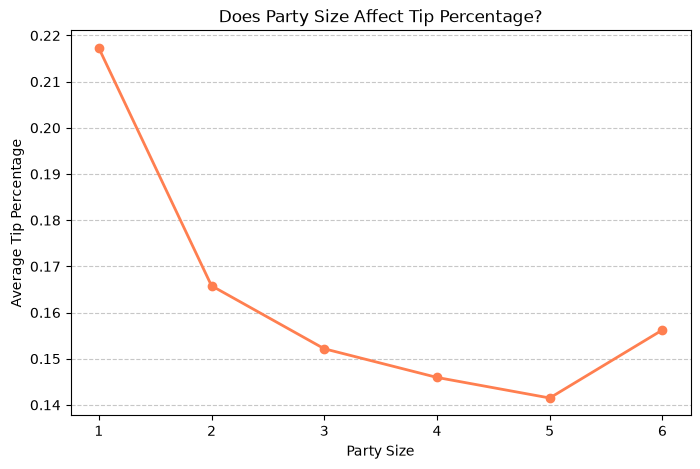

In [67]:
# Calculate the average tip percentage by party size
size_avg_tip = df1.groupby("size")["tip_pct"].mean()
# print(size_avg_tip)

# Build the line chart
plt.figure(figsize=(8, 5))
plt.plot(size_avg_tip.index, size_avg_tip.values, marker='o', color='coral', linewidth=2)
plt.xlabel("Party Size")
plt.ylabel("Average Tip Percentage")
plt.title("Does Party Size Affect Tip Percentage?")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Line Chart Summary

As illustrated in the chart, there is a general **downward trend** in tip percentages as party size increases. Smaller tables (1-2 people) typically leave a higher percentage tip compared to larger groups (5-6 people).

---

## Question: Which day generates the most total revenue?

In [68]:
df1.head()

,total_bill,tip,sex,smoker,day,time,size,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,0.059447
1,10.34,1.66,Male,No,Sun,Dinner,3,0.160542
2,21.01,3.50,Male,No,Sun,Dinner,3,0.166587
3,23.68,3.31,Male,No,Sun,Dinner,2,0.139780
4,24.59,3.61,Female,No,Sun,Dinner,4,0.146808


In [73]:
revenue_according_day = df1.groupby("day")["total_bill"].sum()
revenue_according_day

day
Fri      325.88
Sat     1778.40
Sun     1627.16
Thur    1083.33
Name: total_bill, dtype: float64

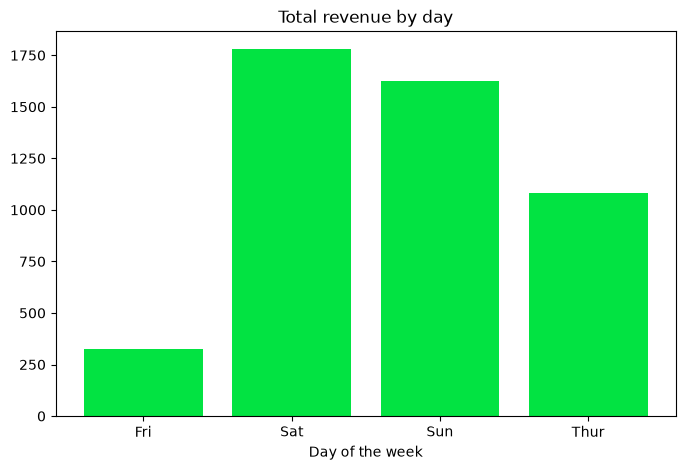

In [76]:
plt.figure(figsize=(8,5))
plt.bar(revenue_according_day.index,revenue_according_day.values,color="#02E342")
plt.title("Total revenue by day")
plt.xlabel("Day of the week")
plt.title("Total revenue by day")
plt.show()

## Bar Chart Summary: Total Revenue

As the chart clearly shows, the weekends drive the bulk of the restaurant's sales:
* **Saturday** is the most profitable day, generating the highest total revenue[cite: 4].
* **Sunday** follows closely behind in second place[cite: 4].
* **Friday** brings in significantly less revenue compared to the other days recorded[cite: 4].

---

## Question: Is the average tip percentage different between lunch and dinner?

In [78]:
avg_time_tip = df1.groupby("time")["tip_pct"].mean()
avg_time_tip

time
Dinner    0.159518
Lunch     0.164281
Name: tip_pct, dtype: float64

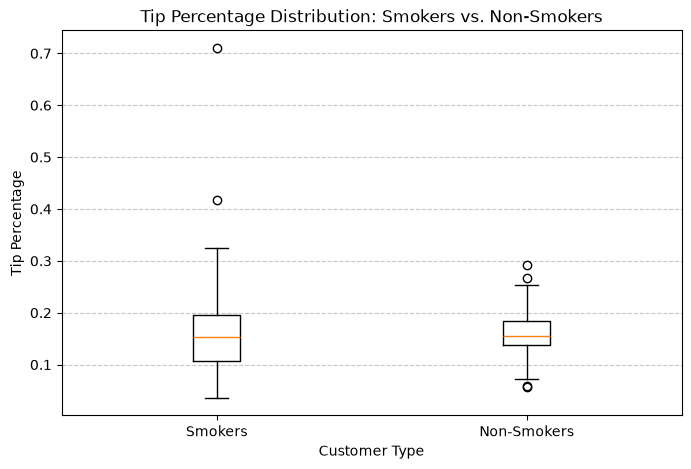

In [79]:
# 1. Separate the data into two groups
smokers = df1[df1['smoker'] == 'Yes']['tip_pct']
non_smokers = df1[df1['smoker'] == 'No']['tip_pct']

# 2. Build the boxplot
plt.figure(figsize=(8, 5))
plt.boxplot([smokers, non_smokers], tick_labels=['Smokers', 'Non-Smokers'])
plt.xlabel("Customer Type")
plt.ylabel("Tip Percentage")
plt.title("Tip Percentage Distribution: Smokers vs. Non-Smokers")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Boxplot Summary: Tip Percentage by Customer Type

* **Similar Averages:** The median tip percentage (the line inside the boxes) is nearly identical for both smokers and non-smokers.
* **Distribution Spread:** The smoker group has a slightly taller box and longer whiskers, indicating a wider variation in their tipping habits—they are slightly less predictable than non-smokers.
* **Outliers:** Both groups feature several dots above the top whisker, representing outliers who left exceptionally high percentage tips.



## Final Project Summary: Tips Dataset Analysis

* **Revenue vs. Tip Rates:** While weekends (Saturday and Sunday) drive the vast majority of the restaurant's total revenue, Friday actually yields the highest average tip percentage from customers.
* **The Party Size Effect:** There is a distinct downward trend in tip percentages as group sizes get larger. Solo diners and couples tend to leave proportionally larger tips than parties of 5 or 6.
* **Customer Habits:** The time of day has a minor impact, with lunch patrons tipping slightly higher percentages than dinner patrons. Meanwhile, a customer's smoking status does not drastically change their median tip percentage, though smokers tend to have slightly more unpredictable tipping habits.